In [23]:
import pandas as pd
from pathlib import Path

In [25]:
# Create a path to our raw data folder
data_path = Path("../data/raw")

# Find every CSV file inside that folder
csv_files = list(data_path.glob("*.csv"))

print("Datasets found:")
for file in csv_files:
    print("-", file.name)

Datasets found:
- olist_sellers_dataset.csv
- product_category_name_translation.csv
- olist_orders_dataset.csv
- olist_order_items_dataset.csv
- olist_customers_dataset.csv
- olist_geolocation_dataset.csv
- olist_order_payments_dataset.csv
- olist_order_reviews_dataset.csv
- olist_products_dataset.csv


In [26]:
# Dictionary to store every dataset
datasets = {}

# Load each CSV into the dictionary
for file in csv_files:
    table_name = file.stem.replace("_dataset", "")
    datasets[table_name] = pd.read_csv(file)

print(f"Successfully loaded {len(datasets)} datasets.\n")

print("Available tables:")
for table in datasets:
    print("-", table)

Successfully loaded 9 datasets.

Available tables:
- olist_sellers
- product_category_name_translation
- olist_orders
- olist_order_items
- olist_customers
- olist_geolocation
- olist_order_payments
- olist_order_reviews
- olist_products


In [27]:
#Display basic info for every dataset

for name, df in datasets.items():
    print('=' * 60)
    print(f"Dataset:{name}")
    print(f"Rows:{df.shape[0]}")
    print(f"Columns:{df.shape[1]}")
    print(f"Column Names:")
    print(list(df.columns))
    print()


Dataset:olist_sellers
Rows:3095
Columns:4
Column Names:
['seller_id', 'seller_zip_code_prefix', 'seller_city', 'seller_state']

Dataset:product_category_name_translation
Rows:71
Columns:2
Column Names:
['product_category_name', 'product_category_name_english']

Dataset:olist_orders
Rows:99441
Columns:8
Column Names:
['order_id', 'customer_id', 'order_status', 'order_purchase_timestamp', 'order_approved_at', 'order_delivered_carrier_date', 'order_delivered_customer_date', 'order_estimated_delivery_date']

Dataset:olist_order_items
Rows:112650
Columns:7
Column Names:
['order_id', 'order_item_id', 'product_id', 'seller_id', 'shipping_limit_date', 'price', 'freight_value']

Dataset:olist_customers
Rows:99441
Columns:5
Column Names:
['customer_id', 'customer_unique_id', 'customer_zip_code_prefix', 'customer_city', 'customer_state']

Dataset:olist_geolocation
Rows:1000163
Columns:5
Column Names:
['geolocation_zip_code_prefix', 'geolocation_lat', 'geolocation_lng', 'geolocation_city', 'geoloc

In [28]:
# Inspect each dataset in detail

for name, df in datasets.items():
    print("=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)

    df.info()

    print("\n")

DATASET: olist_sellers
<class 'pandas.DataFrame'>
RangeIndex: 3095 entries, 0 to 3094
Data columns (total 4 columns):
 #   Column                  Non-Null Count  Dtype
---  ------                  --------------  -----
 0   seller_id               3095 non-null   str  
 1   seller_zip_code_prefix  3095 non-null   int64
 2   seller_city             3095 non-null   str  
 3   seller_state            3095 non-null   str  
dtypes: int64(1), str(3)
memory usage: 230.3 KB


DATASET: product_category_name_translation
<class 'pandas.DataFrame'>
RangeIndex: 71 entries, 0 to 70
Data columns (total 2 columns):
 #   Column                         Non-Null Count  Dtype
---  ------                         --------------  -----
 0   product_category_name          71 non-null     str  
 1   product_category_name_english  71 non-null     str  
dtypes: str(2)
memory usage: 3.5 KB


DATASET: olist_orders
<class 'pandas.DataFrame'>
RangeIndex: 99441 entries, 0 to 99440
Data columns (total 8 columns):
 # 

In [29]:
# Create a summary table for all datasets

summary = []

for name, df in datasets.items():
    summary.append({
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum()
    })

summary_df = pd.DataFrame(summary)

summary_df

,Dataset,Rows,Columns,Missing Values
0,olist_sellers,3095,4,0
1,product_category_name_translation,71,2,0
2,olist_orders,99441,8,4908
3,olist_order_items,112650,7,0
4,olist_customers,99441,5,0
5,olist_geolocation,1000163,5,0
6,olist_order_payments,103886,5,0
7,olist_order_reviews,99224,7,145903
8,olist_products,32951,9,2448


In [30]:
# Check missing values in each dataset

for name, df in datasets.items():

    print("=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)

    missing = df.isnull().sum()

    missing = missing[missing > 0]

    if missing.empty:
        print("✅ No missing values found.")

    else:
        print(missing)

    print()

DATASET: olist_sellers
✅ No missing values found.

DATASET: product_category_name_translation
✅ No missing values found.

DATASET: olist_orders
order_approved_at                 160
order_delivered_carrier_date     1783
order_delivered_customer_date    2965
dtype: int64

DATASET: olist_order_items
✅ No missing values found.

DATASET: olist_customers
✅ No missing values found.

DATASET: olist_geolocation
✅ No missing values found.

DATASET: olist_order_payments
✅ No missing values found.

DATASET: olist_order_reviews
review_comment_title      87656
review_comment_message    58247
dtype: int64

DATASET: olist_products
product_category_name         610
product_name_lenght           610
product_description_lenght    610
product_photos_qty            610
product_weight_g                2
product_length_cm               2
product_height_cm               2
product_width_cm                2
dtype: int64



In [31]:
# Check duplicate rows in each dataset

for name, df in datasets.items():

    duplicates = df.duplicated().sum()

    print("=" * 80)
    print(f"DATASET: {name}")
    print("=" * 80)
    print(f"Duplicate Rows: {duplicates}")
    print()

DATASET: olist_sellers
Duplicate Rows: 0

DATASET: product_category_name_translation
Duplicate Rows: 0

DATASET: olist_orders
Duplicate Rows: 0

DATASET: olist_order_items
Duplicate Rows: 0

DATASET: olist_customers
Duplicate Rows: 0

DATASET: olist_geolocation
Duplicate Rows: 261831

DATASET: olist_order_payments
Duplicate Rows: 0

DATASET: olist_order_reviews
Duplicate Rows: 0

DATASET: olist_products
Duplicate Rows: 0



In [11]:
len(datasets)

9

In [32]:
orders = datasets["olist_orders"]
orders.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00


In [33]:
# Basic statistics for the Orders dataset

orders.describe(include="all")

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date
count,99441,99441,99441,99441,99281,97658,96476,99441
unique,99441,99441,8,98875,90733,81018,95664,459
top,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2018-03-31 15:08:21,2018-02-27 04:31:10,2018-05-09 15:48:00,2018-05-14 20:02:44,2017-12-20 00:00:00
freq,1,1,96478,3,9,47,3,522


In [34]:
# Count the number of orders in each status

status_counts = orders["order_status"].value_counts()

status_counts

order_status
delivered      96478
shipped         1107
canceled         625
unavailable      609
invoiced         314
processing       301
created            5
approved           2
Name: count, dtype: int64

In [35]:
# Calculate percentage of each order status

status_percentage = (
    orders["order_status"]
    .value_counts(normalize=True)
    .mul(100)
    .round(2)
)

status_percentage

order_status
delivered      97.02
shipped         1.11
canceled        0.63
unavailable     0.61
invoiced        0.32
processing      0.30
created         0.01
approved        0.00
Name: proportion, dtype: float64

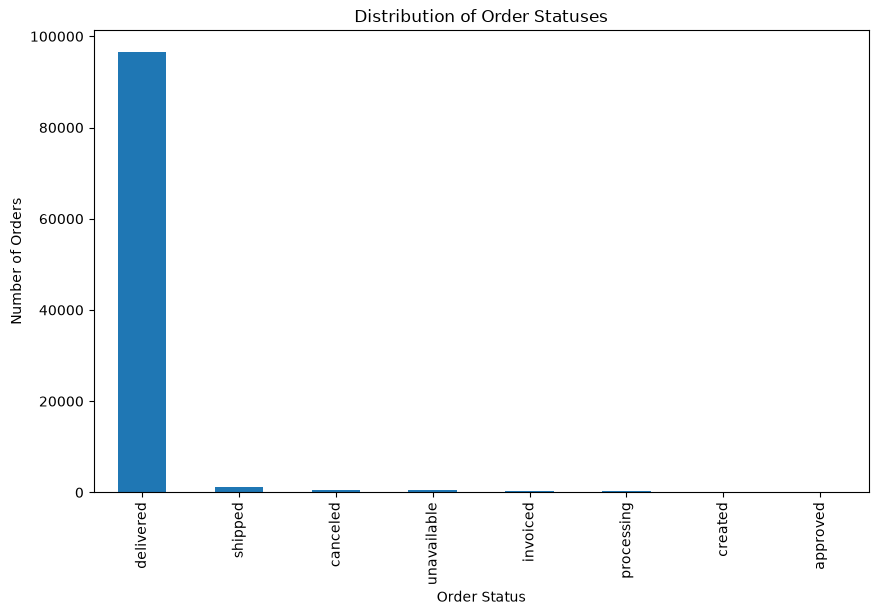

In [37]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10, 6))

status_counts.plot(kind="bar")

plt.title("Distribution of Order Statuses")
plt.xlabel("Order Status")
plt.ylabel("Number of Orders")

plt.show()

In [38]:
# Convert purchase timestamp to datetime

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

orders["order_purchase_timestamp"].head()

0   2017-10-02 10:56:33
1   2018-07-24 20:41:37
2   2018-08-08 08:38:49
3   2017-11-18 19:28:06
4   2018-02-13 21:18:39
Name: order_purchase_timestamp, dtype: datetime64[us]

In [39]:
# Extract Year-Month from the purchase timestamp

orders["order_month"] = orders["order_purchase_timestamp"].dt.to_period("M")

orders[["order_purchase_timestamp", "order_month"]].head()

,order_purchase_timestamp,order_month
0,2017-10-02 10:56:33,2017-10
1,2018-07-24 20:41:37,2018-07
2,2018-08-08 08:38:49,2018-08
3,2017-11-18 19:28:06,2017-11
4,2018-02-13 21:18:39,2018-02


In [40]:
monthly_orders = (
    orders
    .groupby("order_month")
    .size()
)

monthly_orders

order_month
2016-09       4
2016-10     324
2016-12       1
2017-01     800
2017-02    1780
2017-03    2682
2017-04    2404
2017-05    3700
2017-06    3245
2017-07    4026
2017-08    4331
2017-09    4285
2017-10    4631
2017-11    7544
2017-12    5673
2018-01    7269
2018-02    6728
2018-03    7211
2018-04    6939
2018-05    6873
2018-06    6167
2018-07    6292
2018-08    6512
2018-09      16
2018-10       4
Freq: M, dtype: int64

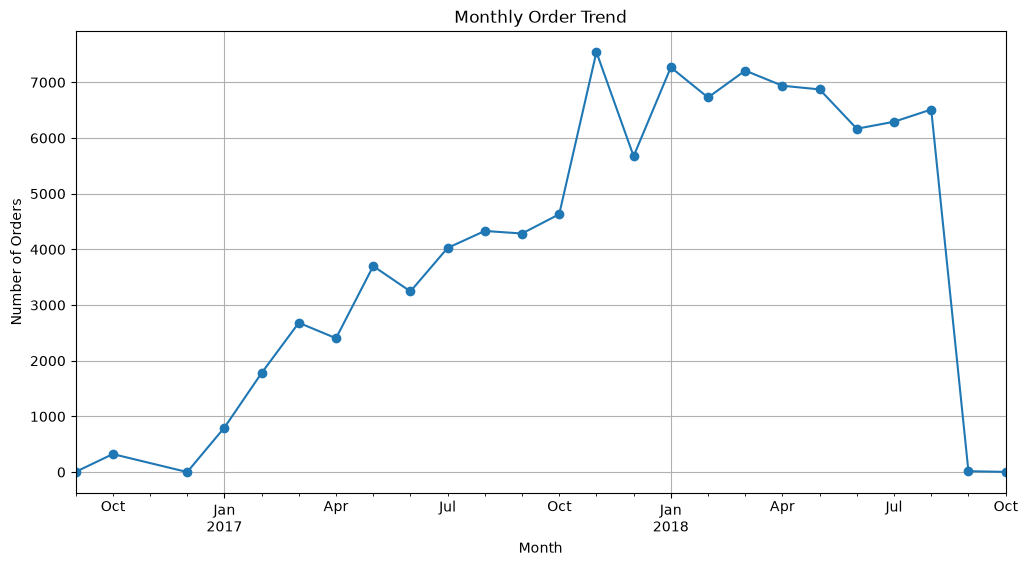

In [41]:
# Plot monthly order trend

import matplotlib.pyplot as plt

plt.figure(figsize=(12, 6))

monthly_orders.plot(kind="line", marker="o")

plt.title("Monthly Order Trend")
plt.xlabel("Month")
plt.ylabel("Number of Orders")

plt.grid(True)

plt.show()

In [21]:
## Business Insight

Order volume demonstrates strong growth throughout the observation period, indicating increasing business activity.
A noticeable spike occurs towards the end of 2017, which may be associated with seasonal shopping events or promotional campaigns.
The sharp decline in the final month is likely due to incomplete data rather than an actual reduction in business performance.

SyntaxError: invalid syntax (544845351.py, line 3)

In [42]:
order_items = datasets["olist_order_items"]

order_items.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14


In [43]:
# Calculate revenue for each order

order_revenue = (
    order_items
    .groupby("order_id")["price"]
    .sum()
    .reset_index()
)

order_revenue.head()

,order_id,price
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [44]:
# Merge Orders with Revenue

orders_with_revenue = orders.merge(
    order_revenue,
    on="order_id",
    how="left"
)

orders_with_revenue.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,price
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02,19.90


In [45]:
order_revenue = order_revenue.rename(columns={"price": "order_revenue"})

order_revenue.head()

,order_id,order_revenue
0,00010242fe8c5a6d1ba2dd792cb16214,58.90
1,00018f77f2f0320c557190d7a144bdd3,239.90
2,000229ec398224ef6ca0657da4fc703e,199.00
3,00024acbcdf0a6daa1e931b038114c75,12.99
4,00042b26cf59d7ce69dfabb4e55b4fd9,199.90


In [46]:
orders_with_revenue = orders.merge(
    order_revenue,
    on="order_id",
    how="left"
)

orders_with_revenue.head()

,order_id,customer_id,order_status,order_purchase_timestamp,order_approved_at,order_delivered_carrier_date,order_delivered_customer_date,order_estimated_delivery_date,order_month,order_revenue
0,e481f51cbdc54678b7cc49136f2d6af7,9ef432eb6251297304e76186b10a928d,delivered,2017-10-02 10:56:33,2017-10-02 11:07:15,2017-10-04 19:55:00,2017-10-10 21:25:13,2017-10-18 00:00:00,2017-10,29.99
1,53cdb2fc8bc7dce0b6741e2150273451,b0830fb4747a6c6d20dea0b8c802d7ef,delivered,2018-07-24 20:41:37,2018-07-26 03:24:27,2018-07-26 14:31:00,2018-08-07 15:27:45,2018-08-13 00:00:00,2018-07,118.70
2,47770eb9100c2d0c44946d9cf07ec65d,41ce2a54c0b03bf3443c3d931a367089,delivered,2018-08-08 08:38:49,2018-08-08 08:55:23,2018-08-08 13:50:00,2018-08-17 18:06:29,2018-09-04 00:00:00,2018-08,159.90
3,949d5b44dbf5de918fe9c16f97b45f8a,f88197465ea7920adcdbec7375364d82,delivered,2017-11-18 19:28:06,2017-11-18 19:45:59,2017-11-22 13:39:59,2017-12-02 00:28:42,2017-12-15 00:00:00,2017-11,45.00
4,ad21c59c0840e6cb83a9ceb5573f8159,8ab97904e6daea8866dbdbc4fb7aad2c,delivered,2018-02-13 21:18:39,2018-02-13 22:20:29,2018-02-14 19:46:34,2018-02-16 18:17:02,2018-02-26 00:00:00,2018-02,19.90


In [48]:
# Total revenue generated

total_revenue = orders_with_revenue["order_revenue"].sum()

print(f"Total Revenue: R$ {total_revenue:,.2f}")

Total Revenue: R$ 13,591,643.70


In [49]:
# Average Order Value

average_order_value = orders_with_revenue["order_revenue"].mean()

print(f"Average Order Value: R$ {average_order_value:.2f}")

Average Order Value: R$ 137.75


In [50]:
# Load Products table

products = datasets["olist_products"]

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0


In [51]:
# Load category translation table

translations = datasets["product_category_name_translation"]

translations.head()

,product_category_name,product_category_name_english
0,beleza_saude,health_beauty
1,informatica_acessorios,computers_accessories
2,automotivo,auto
3,cama_mesa_banho,bed_bath_table
4,moveis_decoracao,furniture_decor


In [52]:
products = products.merge(
    translations,
    on="product_category_name",
    how="left"
)

products.head()

,product_id,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,1e9e8ef04dbcff4541ed26657ea517e5,perfumaria,40.0,287.0,1.0,225.0,16.0,10.0,14.0,perfumery
1,3aa071139cb16b67ca9e5dea641aaa2f,artes,44.0,276.0,1.0,1000.0,30.0,18.0,20.0,art
2,96bd76ec8810374ed1b65e291975717f,esporte_lazer,46.0,250.0,1.0,154.0,18.0,9.0,15.0,sports_leisure
3,cef67bcfe19066a932b7673e239eb23d,bebes,27.0,261.0,1.0,371.0,26.0,4.0,26.0,baby
4,9dc1a7de274444849c219cff195d0b71,utilidades_domesticas,37.0,402.0,4.0,625.0,20.0,17.0,13.0,housewares


In [53]:
order_products = order_items.merge(
    products,
    on="product_id",
    how="left"
)

order_products.head()

,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value,product_category_name,product_name_lenght,product_description_lenght,product_photos_qty,product_weight_g,product_length_cm,product_height_cm,product_width_cm,product_category_name_english
0,00010242fe8c5a6d1ba2dd792cb16214,1,4244733e06e7ecb4970a6e2683c13e61,48436dade18ac8b2bce089ec2a041202,2017-09-19 09:45:35,58.90,13.29,cool_stuff,58.0,598.0,4.0,650.0,28.0,9.0,14.0,cool_stuff
1,00018f77f2f0320c557190d7a144bdd3,1,e5f2d52b802189ee658865ca93d83a8f,dd7ddc04e1b6c2c614352b383efe2d36,2017-05-03 11:05:13,239.90,19.93,pet_shop,56.0,239.0,2.0,30000.0,50.0,30.0,40.0,pet_shop
2,000229ec398224ef6ca0657da4fc703e,1,c777355d18b72b67abbeef9df44fd0fd,5b51032eddd242adc84c38acab88f23d,2018-01-18 14:48:30,199.00,17.87,moveis_decoracao,59.0,695.0,2.0,3050.0,33.0,13.0,33.0,furniture_decor
3,00024acbcdf0a6daa1e931b038114c75,1,7634da152a4610f1595efa32f14722fc,9d7a1d34a5052409006425275ba1c2b4,2018-08-15 10:10:18,12.99,12.79,perfumaria,42.0,480.0,1.0,200.0,16.0,10.0,15.0,perfumery
4,00042b26cf59d7ce69dfabb4e55b4fd9,1,ac6c3623068f30de03045865e4e10089,df560393f3a51e74553ab94004ba5c87,2017-02-13 13:57:51,199.90,18.14,ferramentas_jardim,59.0,409.0,1.0,3750.0,35.0,40.0,30.0,garden_tools


In [54]:
# Check for invalid prices

invalid_prices = order_items[order_items["price"] <= 0]

print(f"Invalid price records: {len(invalid_prices)}")

invalid_prices.head()

Invalid price records: 0


,order_id,order_item_id,product_id,seller_id,shipping_limit_date,price,freight_value


In [55]:
# Data Quality Summary

quality_report = []

for name, df in datasets.items():

    report = {
        "Dataset": name,
        "Rows": df.shape[0],
        "Columns": df.shape[1],
        "Missing Values": df.isnull().sum().sum(),
        "Duplicate Rows": df.duplicated().sum()
    }

    quality_report.append(report)

quality_report = pd.DataFrame(quality_report)

quality_report

,Dataset,Rows,Columns,Missing Values,Duplicate Rows
0,olist_sellers,3095,4,0,0
1,product_category_name_translation,71,2,0,0
2,olist_orders,99441,9,4908,0
3,olist_order_items,112650,7,0,0
4,olist_customers,99441,5,0,0
5,olist_geolocation,1000163,5,0,261831
6,olist_order_payments,103886,5,0,0
7,olist_order_reviews,99224,7,145903,0
8,olist_products,32951,9,2448,0


In [56]:
# Customer Summary

customer_summary = (
    orders_with_revenue
    .groupby("customer_id")
    .agg(
        Total_Orders=("order_id", "count"),
        Total_Revenue=("order_revenue", "sum"),
        Average_Order_Value=("order_revenue", "mean")
    )
    .reset_index()
)

customer_summary.head()

,customer_id,Total_Orders,Total_Revenue,Average_Order_Value
0,00012a2ce6f8dcda20d059ce98491703,1,89.80,89.80
1,000161a058600d5901f007fab4c27140,1,54.90,54.90
2,0001fd6190edaaf884bcaf3d49edf079,1,179.99,179.99
3,0002414f95344307404f0ace7a26f1d5,1,149.90,149.90
4,000379cdec625522490c315e70c7a9fb,1,93.00,93.00


In [57]:
top_customers = (
    customer_summary
    .sort_values("Total_Revenue", ascending=False)
    .head(10)
)

top_customers

,customer_id,Total_Orders,Total_Revenue,Average_Order_Value
8546,1617b1357756262bfa56ab541c47bc16,1,13440.0,13440.0
91985,ec5b2ba62e574342386871631fafd3fc,1,7160.0,7160.0
77522,c6e2731c5b391845f6800c97401a43a9,1,6735.0,6735.0
95124,f48d464a0baaea338cb25f816991ab1f,1,6729.0,6729.0
24771,3fd6777bbce08a352fddd04e4a7cc8f6,1,6499.0,6499.0
2065,05455dfa7cd02f13d132aa7a6a9729c6,1,5934.6,5934.6
86908,df55c14d1476a9a3467f131269c2477f,1,4799.0,4799.0
14282,24bbf5fd2f2e1b359ee7de94defc4a15,1,4690.0,4690.0
87397,e0a2412720e9ea4f26c1ac985f6a7358,1,4599.9,4599.9
23932,3d979689f636322c62418b6346b1c6d2,1,4590.0,4590.0


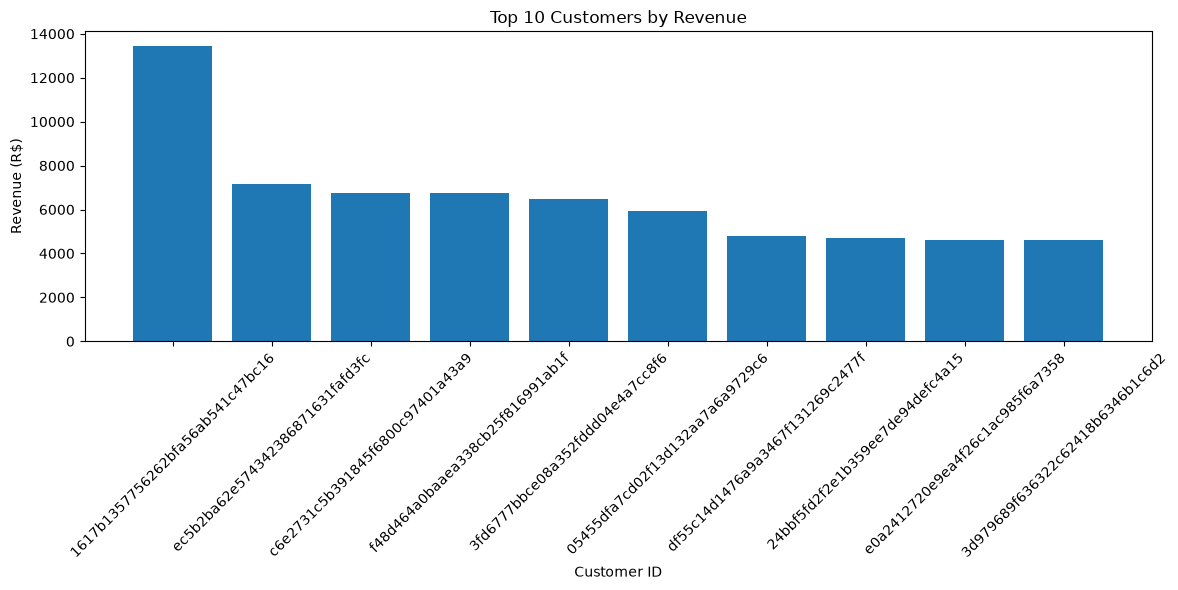

In [58]:
plt.figure(figsize=(12,6))

plt.bar(
    top_customers["customer_id"],
    top_customers["Total_Revenue"]
)

plt.title("Top 10 Customers by Revenue")
plt.xlabel("Customer ID")
plt.ylabel("Revenue (R$)")

plt.xticks(rotation=45)

plt.tight_layout()

plt.show()

In [59]:
total_orders = orders["order_id"].nunique()

print(f"Total Orders: {total_orders:,}")

Total Orders: 99,441


In [60]:
customers = datasets["olist_customers"]

total_customers = customers["customer_unique_id"].nunique()

print(f"Total Customers: {total_customers:,}")

Total Customers: 96,096


In [62]:
orders["order_delivered_customer_date"] = pd.to_datetime(
    orders["order_delivered_customer_date"]
)

orders["order_purchase_timestamp"] = pd.to_datetime(
    orders["order_purchase_timestamp"]
)

In [65]:
orders["delivery_days"] = (
    orders["order_delivered_customer_date"]
    - orders["order_purchase_timestamp"]
).dt.days

In [64]:
average_delivery = orders["delivery_days"].mean()

print(f"Average Delivery Time: {average_delivery:.2f} days")

Average Delivery Time: 12.09 days


In [66]:
# Orders placed by each customer

customer_orders = (
    orders
    .groupby("customer_id")
    .size()
    .reset_index(name="order_count")
)

customer_orders.head()

,customer_id,order_count
0,00012a2ce6f8dcda20d059ce98491703,1
1,000161a058600d5901f007fab4c27140,1
2,0001fd6190edaaf884bcaf3d49edf079,1
3,0002414f95344307404f0ace7a26f1d5,1
4,000379cdec625522490c315e70c7a9fb,1


In [67]:
repeat_customers = customer_orders[
    customer_orders["order_count"] > 1
]

repeat_customers.head()

,customer_id,order_count


In [68]:
repeat_rate = (
    len(repeat_customers)
    / len(customer_orders)
) * 100

print(f"Repeat Customer Rate: {repeat_rate:.2f}%")

Repeat Customer Rate: 0.00%


In [70]:
# Executive KPI Table

kpis = pd.DataFrame({
    "KPI": [
        "Total Revenue",
        "Total Orders",
        "Total Customers",
        "Average Order Value",
        "Average Delivery Time"
    ],
    "Value": [
        total_revenue,
        total_orders,
        total_customers,
        average_order_value,
        average_delivery
    ]
})

kpis

,KPI,Value
0,Total Revenue,1.359164e+07
1,Total Orders,9.944100e+04
2,Total Customers,9.609600e+04
3,Average Order Value,1.377541e+02
4,Average Delivery Time,1.209409e+01


In [71]:
kpis.to_csv(
    "../reports/executive_kpis.csv",
    index=False
)

In [72]:
import os

os.listdir("../reports")

['executive_kpis.csv']